In [17]:
!pip install dmba
!pip install mord

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from mord import LogisticIT
import matplotlib.pylab as plt
%matplotlib inline
import seaborn as sns
from dmba import classificationSummary, gainsChart, liftChart
from dmba import backward_elimination, classificationSummary, AIC_score

In [18]:
df = pd.read_csv('D600 Task 2 Dataset 1 Housing Information.csv')

In [19]:
df.dtypes

ID                        int64
Price                   float64
SquareFootage           float64
NumBathrooms            float64
NumBedrooms               int64
BackyardSpace           float64
CrimeRate               float64
SchoolRating            float64
AgeOfHome               float64
DistanceToCityCenter    float64
EmploymentRate          float64
PropertyTaxRate         float64
RenovationQuality       float64
LocalAmenities          float64
TransportAccess         float64
Fireplace                object
HouseColor               object
Garage                   object
Floors                    int64
Windows                   int64
PreviousSalePrice       float64
IsLuxury                  int64
dtype: object

In [20]:
df.describe(include='all')

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
count,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,...,7000.000000,7000.000000,7000.000000,7000,7000,7000,7000.00000,7000.000000,7.000000e+03,7000.00000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2,5,2,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,No,White,No,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5172,1446,4488,NaN,NaN,NaN,NaN
mean,3500.500000,3.072820e+05,1048.947459,2.131397,3.008571,511.507029,31.226194,6.942923,46.797046,17.475337,...,5.003357,5.934579,5.983860,NaN,NaN,NaN,1.16300,16.248857,2.845094e+05,0.50400
std,2020.870275,1.501734e+05,426.010482,0.952561,1.021940,279.926549,18.025327,1.888148,31.779701,12.024985,...,1.970428,2.657930,1.953974,NaN,NaN,NaN,0.37209,8.926479,1.857340e+05,0.50002
min,1.000000,8.500000e+04,550.000000,1.000000,1.000000,0.390000,0.030000,0.220000,0.010000,0.000000,...,0.010000,0.000000,0.010000,NaN,NaN,NaN,1.00000,-6.000000,-8.356902e+03,0.00000
25%,1750.750000,1.921075e+05,660.815000,1.290539,2.000000,300.995000,17.390000,5.650000,20.755000,7.827500,...,3.660000,4.000000,4.680000,NaN,NaN,NaN,1.00000,11.000000,1.420140e+05,0.00000
50%,3500.500000,2.793230e+05,996.320000,1.997774,3.000000,495.965000,30.385000,7.010000,42.620000,15.625000,...,5.020000,6.040000,6.000000,NaN,NaN,NaN,1.00000,15.000000,2.621831e+05,1.00000
75%,5250.250000,3.918781e+05,1342.292500,2.763997,4.000000,704.012500,43.670000,8.360000,67.232500,25.222500,...,6.350000,8.050000,7.350000,NaN,NaN,NaN,1.00000,20.000000,3.961212e+05,1.00000


In [21]:
df['IsLuxury'].value_counts()

IsLuxury
1    3528
0    3472
Name: count, dtype: int64

In [22]:
features = ['SquareFootage', 'NumBathrooms', 'CrimeRate', 'SchoolRating',
            'RenovationQuality', 'LocalAmenities', 'DistanceToCityCenter', 'Garage']
outcome = ['IsLuxury']
df[features].describe()

,SquareFootage,NumBathrooms,CrimeRate,SchoolRating,RenovationQuality,LocalAmenities,DistanceToCityCenter
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,1048.947459,2.131397,31.226194,6.942923,5.003357,5.934579,17.475337
std,426.010482,0.952561,18.025327,1.888148,1.970428,2.657930,12.024985
min,550.000000,1.000000,0.030000,0.220000,0.010000,0.000000,0.000000
25%,660.815000,1.290539,17.390000,5.650000,3.660000,4.000000,7.827500
50%,996.320000,1.997774,30.385000,7.010000,5.020000,6.040000,15.625000
75%,1342.292500,2.763997,43.670000,8.360000,6.350000,8.050000,25.222500
max,2874.700000,5.807239,99.730000,10.000000,10.000000,10.000000,65.200000


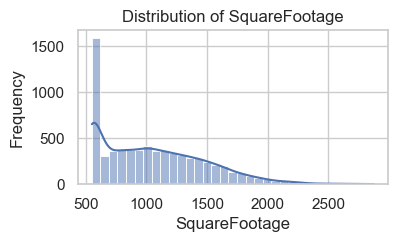

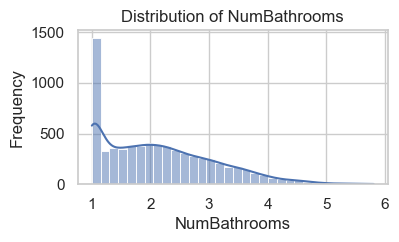

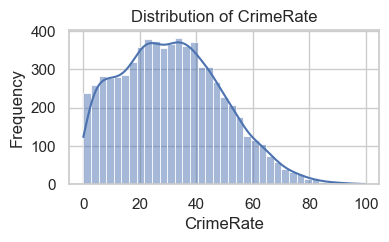

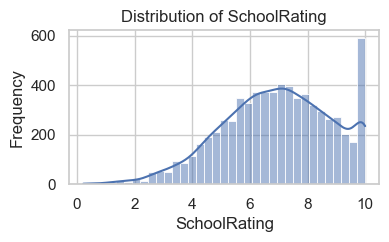

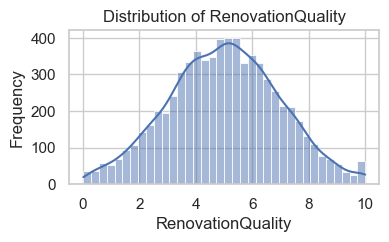

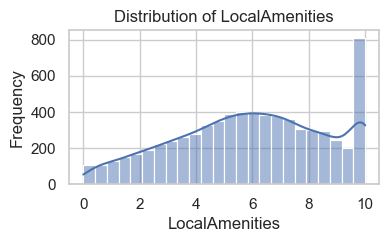

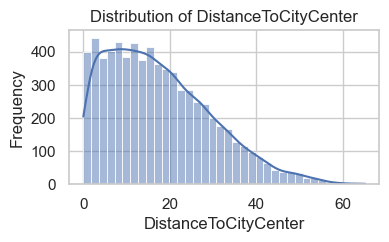

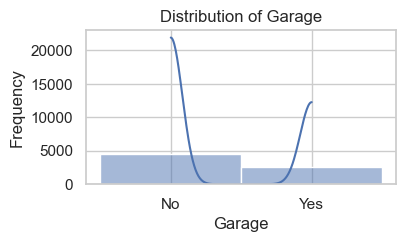

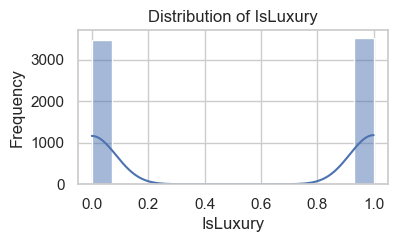

In [23]:
%matplotlib inline
sns.set(style="whitegrid")

for feature1 in features:
    plt.figure(figsize=(4, 2))
    sns.histplot(df[feature1], kde=True)
    plt.title(f'Distribution of {feature1}')
    plt.xlabel(feature1)
    plt.ylabel('Frequency')
    plt.show()

for outcome1 in outcome:
    plt.figure(figsize=(4, 2))
    sns.histplot(df[outcome1], kde=True)
    plt.title(f'Distribution of {outcome1}')
    plt.xlabel(outcome1)
    plt.ylabel('Frequency')
    plt.show()

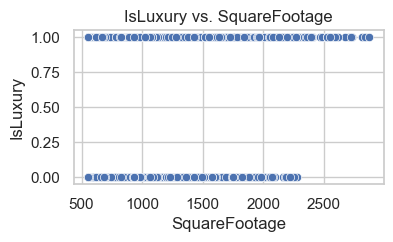

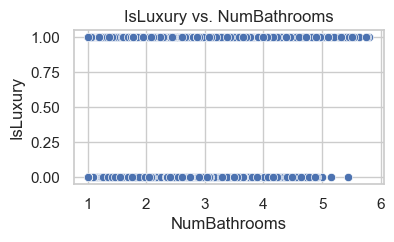

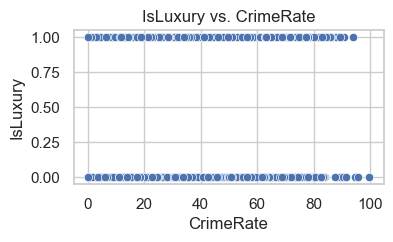

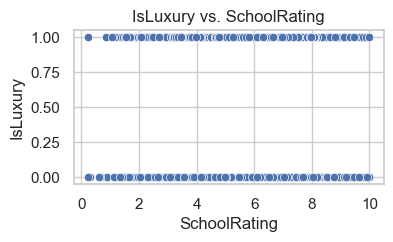

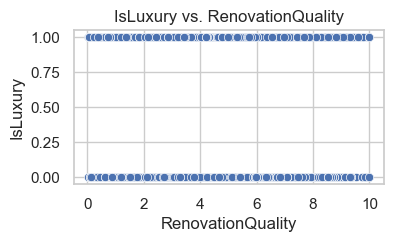

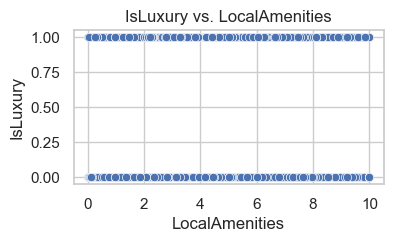

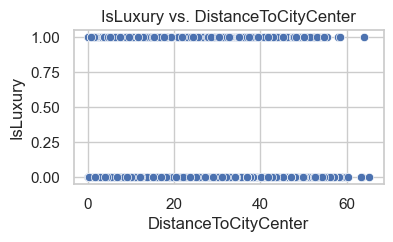

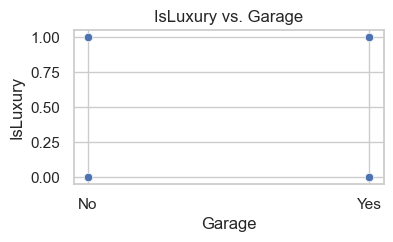

In [24]:
%matplotlib inline
for feature2 in features: 
    plt.figure(figsize=(4, 2))
    sns.scatterplot(x=df[feature2], y=df['IsLuxury'])
    plt.title(f'IsLuxury vs. {feature2}')
    plt.xlabel(feature2)
    plt.ylabel('IsLuxury')
    plt.show()

In [25]:
X = pd.get_dummies(df[features], drop_first=True)
y = pd.get_dummies(df[outcome], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)


In [26]:
train_data = pd.concat([y_train, X_train], axis=1)
test_data = pd.concat([y_test, X_test], axis=1)

train_data.to_csv('X_train.csv', index=False)
test_data.to_csv('X_test.csv', index=False)

In [27]:
def train_model(variables):
    model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
    model.fit(X_train[variables], y_train.squeeze())
    return model

# Score model using AIC
def score_model(model, variables):
    # Predict probabilities for class 1
    y_pred_prob = model.predict_proba(X_train[variables])[:, 1]
    return AIC_score(y_train, y_pred_prob, model)

# Get list of all variables
allVariables = list(X_train.columns)

# Run backward elimination
best_model, best_variables = backward_elimination(allVariables, train_model, score_model, verbose=True)

# Output selected variables
print("Selected variables:", best_variables)

# Evaluate on test set
classificationSummary(y_test, best_model.predict(X_test[best_variables]))

Variables: SquareFootage, NumBathrooms, CrimeRate, SchoolRating, RenovationQuality, LocalAmenities, DistanceToCityCenter, Garage_Yes
Start: score=42026.26
Step: score=41828.92, remove SquareFootage
Step: score=41702.34, remove NumBathrooms
Step: score=41509.58, remove RenovationQuality
Step: score=41278.01, remove SchoolRating
Step: score=41210.46, remove DistanceToCityCenter
Step: score=41145.26, remove LocalAmenities
Step: score=41142.59, remove CrimeRate
Selected variables: ['Garage_Yes']
Confusion Matrix (Accuracy 0.4946)

       Prediction
Actual   0   1
     0 862 508
     1 907 523


In [28]:
import numpy as np

X_train = np.asarray(X_train, dtype=float)
y_train = np.asarray(y_train, dtype=float).ravel()

X_test = np.asarray(X_train, dtype=float)
y_test = np.asarray(y_train, dtype=float).ravel()

X_train_sm = sm.add_constant(X_train)

model = sm.Logit(y_train, X_train_sm).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.562620
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4200
Model:                          Logit   Df Residuals:                     4191
Method:                           MLE   Df Model:                            8
Date:                Wed, 23 Jul 2025   Pseudo R-squ.:                  0.1883
Time:                        01:30:26   Log-Likelihood:                -2363.0
converged:                       True   LL-Null:                       -2911.2
Covariance Type:            nonrobust   LLR p-value:                2.269e-231
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5898      0.225    -20.363      0.000      -5.032      -4.148
x1             0.0016   9.61e

In [29]:
logit_reg = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg.fit(X_train, y_train)

print('intercept ', logit_reg.intercept_[0])
print(pd.DataFrame({'coeff': logit_reg.coef_[0]}, index=X.columns).transpose())

print('AIC', AIC_score(y_test, logit_reg.predict(X_train), df = len(X.columns) + 1))


intercept  -4.511218240670003
       SquareFootage  NumBathrooms  CrimeRate  SchoolRating  \
coeff       0.001553      0.522165   0.002302      0.102423   

       RenovationQuality  LocalAmenities  DistanceToCityCenter  Garage_Yes  
coeff           0.168463        0.044187             -0.006601    0.049805  
AIC 6606.889314309904


In [30]:
classificationSummary(y_train, logit_reg.predict(X_train))

classificationSummary(y_test, logit_reg.predict(X_test))

Confusion Matrix (Accuracy 0.7190)

       Prediction
Actual    0    1
     0 1536  566
     1  614 1484
Confusion Matrix (Accuracy 0.7190)

       Prediction
Actual    0    1
     0 1536  566
     1  614 1484


In [31]:
logit_reg_pred = logit_reg.predict(X_test)
logit_reg_proba = logit_reg.predict_proba(X_test)
logit_result = pd.DataFrame({'actual': y_test, 
                             'p(0)': [p[0] for p in logit_reg_proba],
                             'p(1)': [p[1] for p in logit_reg_proba],
                             'predicted': logit_reg_pred })
interestingCases = [2764, 932, 2721, 702, 500, 200, 4000, 900, 700]
print(logit_result.loc[interestingCases])

      actual      p(0)      p(1)  predicted
2764     0.0  0.684256  0.315744        0.0
932      0.0  0.474906  0.525094        1.0
2721     0.0  0.688683  0.311317        0.0
702      1.0  0.227697  0.772303        1.0
500      0.0  0.856364  0.143636        0.0
200      1.0  0.439438  0.560562        1.0
4000     1.0  0.248764  0.751236        1.0
900      0.0  0.775843  0.224157        0.0
700      1.0  0.450728  0.549272        1.0


In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Ensure X_train is a DataFrame for column names
X_train_df = pd.DataFrame(X_train, columns=[f'X{i}' for i in range(X_train.shape[1])])

# Add constant term to match the logistic regression model
X_train_const = sm.add_constant(X_train_df)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i) for i in range(X_train_const.shape[1])]

print(vif_data)

  Variable        VIF
0    const  33.389965
1       X0   1.208182
2       X1   1.140143
3       X2   1.040410
4       X3   1.400571
5       X4   1.566024
6       X5   1.048349
7       X6   1.067076
8       X7   1.001429
